In [6]:
import numpy as np
import pandas as pd
df = pd.read_csv('C:\Documents\PTIT\PTHTTM\gianha.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 2.8 MB


In [7]:
print("Nulls")
print("=====")
print(df.isnull().sum())

Nulls
=====
Address                  0
Area                     0
Frontage             11564
Access Road          13297
House direction      21239
Balcony direction    24983
Floors                3603
Bedrooms              5162
Bathrooms             7074
Legal status          4506
Furniture state      14119
Price                    0
dtype: int64


In [8]:
print("0s")
print("==")
print(df.eq(0).sum())

0s
==
Address              0
Area                 0
Frontage             0
Access Road          0
House direction      0
Balcony direction    0
Floors               0
Bedrooms             0
Bathrooms            0
Legal status         0
Furniture state      0
Price                0
dtype: int64


In [10]:
print("Số dòng bị trùng lặp:", df.duplicated().sum())

Số dòng bị trùng lặp: 0


In [11]:
print("Số lượng giá trị khác nhau của từng cột:")
print("========================================")

for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Số lượng giá trị khác nhau của từng cột:
Address: 10265
Area: 1512
Frontage: 407
Access Road: 140
House direction: 8
Balcony direction: 8
Floors: 10
Bedrooms: 9
Bathrooms: 9
Legal status: 2
Furniture state: 2
Price: 687


In [12]:
print(df["Address"].head(20).to_string(index=False))

Dự án The Empire - Vinhomes Ocean Park 2, Xã Lo...
Dự án The Crown - Vinhomes Ocean Park 3, Xã Ngh...
Dự án The Crown - Vinhomes Ocean Park 3, Xã Ngh...
Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ Ch...
  Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh
Dự án The Empire - Vinhomes Ocean Park 2, Xã Lo...
Dự án The Empire - Vinhomes Ocean Park 2, Xã Lo...
Dự án Him Lam Thường Tín, Huyện Thường Tín, Hà Nội
Dự án The Empire - Vinhomes Ocean Park 2, Xã Lo...
Dự án The Crown - Vinhomes Ocean Park 3, Xã Ngh...
Dự án The Crown - Vinhomes Ocean Park 3, Xã Ngh...
Dự án The Crown - Vinhomes Ocean Park 3, Xã Ngh...
Dự án The Crown - Vinhomes Ocean Park 3, Xã Ngh...
Dự án The Empire - Vinhomes Ocean Park 2, Xã Lo...
Dự án The Empire - Vinhomes Ocean Park 2, Xã Lo...
Đường Phạm Văn Chiêu, Phường 14, Gò Vấp, Hồ Chí...
Dự án Khu đô thị Phương Đông, Xã Đông Xá, Vân Đ...
Dự án The Crown - Vinhomes Ocean Park 3, Xã Ngh...
Dự án The Empire - Vinhomes Ocean Park 2, Xã Lo...
 Đường Quang Trung, Phường 12, 

In [13]:
categorical_cols = [
    "House direction",
    "Balcony direction",
    "Legal status",
    "Furniture state"
]

for col in categorical_cols:
    print("\n", "=" * 50)
    print("Cột:", col)
    print("=" * 50)
    print(df[col].value_counts(dropna=False))


Cột: House direction
House direction
NaN           21239
Đông - Nam     1916
Đông - Bắc     1180
Tây - Nam      1152
Tây - Bắc      1125
Nam            1042
Đông            952
Bắc             832
Tây             791
Name: count, dtype: int64

Cột: Balcony direction
Balcony direction
NaN           24983
Đông - Nam     1087
Nam             701
Đông - Bắc      670
Tây - Nam       646
Tây - Bắc       640
Đông            577
Bắc             474
Tây             451
Name: count, dtype: int64

Cột: Legal status
Legal status
Have certificate    24774
NaN                  4506
Sale contract         949
Name: count, dtype: int64

Cột: Furniture state
Furniture state
NaN      14119
Full     10591
Basic     5519
Name: count, dtype: int64


In [14]:
numeric_cols = [
    "Area",
    "Frontage",
    "Access Road",
    "Floors",
    "Bedrooms",
    "Bathrooms",
    "Price"
]

df[numeric_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Area,30229.0,68.498741,48.069835,3.1,21.00,30.0,40.0,56.0,80.0,148.62,275.72,595.0
Frontage,18665.0,5.361692,4.346174,1.0,3.00,3.3,4.0,4.5,5.0,9.00,29.36,77.0
Access Road,16932.0,7.853800,7.451313,1.0,2.00,2.5,4.0,6.0,10.0,20.00,40.00,85.0
Floors,26626.0,3.410426,1.328897,1.0,1.00,1.0,2.0,3.0,4.0,5.00,6.00,10.0
Bedrooms,25067.0,3.511030,1.309116,1.0,1.00,2.0,3.0,3.0,4.0,6.00,8.00,9.0
Bathrooms,23155.0,3.346837,1.400181,1.0,1.00,1.0,2.0,3.0,4.0,6.00,8.00,9.0
Price,30229.0,5.872078,2.211877,1.0,1.45,2.2,4.2,5.9,7.5,9.50,10.00,11.5


In [15]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing

,Missing Values,Percentage (%)
Address,0,0.00
Area,0,0.00
Frontage,11564,38.25
Access Road,13297,43.99
House direction,21239,70.26
Balcony direction,24983,82.65
Floors,3603,11.92
Bedrooms,5162,17.08
Bathrooms,7074,23.40
Legal status,4506,14.91


In [16]:
df_clean = df.copy()

print("Kích thước dữ liệu ban đầu:", df_clean.shape)

Kích thước dữ liệu ban đầu: (30229, 12)


In [17]:
print("Số dòng trùng lặp:", df_clean.duplicated().sum())

Số dòng trùng lặp: 0


In [18]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Kích thước sau khi xóa trùng:", df_clean.shape)

Kích thước sau khi xóa trùng: (30229, 12)


In [19]:
def extract_city(address):
    parts = [part.strip() for part in str(address).split(",")]
    
    if len(parts) >= 1:
        return parts[-1]
    
    return "Unknown"


def extract_district(address):
    parts = [part.strip() for part in str(address).split(",")]
    
    if len(parts) >= 2:
        return parts[-2]
    
    return "Unknown"


df_clean["City"] = df_clean["Address"].apply(extract_city)
df_clean["District"] = df_clean["Address"].apply(extract_district)

df_clean[["Address", "District", "City"]].head(20)

,Address,District,City
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",Văn Giang,Hưng Yên
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",Văn Giang,Hưng Yên
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",Văn Giang,Hưng Yên
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",Gò Vấp,Hồ Chí Minh
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",Gò Vấp,Hồ Chí Minh
5,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",Văn Giang,Hưng Yên
6,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",Văn Giang,Hưng Yên
7,"Dự án Him Lam Thường Tín, Huyện Thường Tín, Hà...",Huyện Thường Tín,Hà Nội
8,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",Văn Giang,Hưng Yên
9,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",Văn Giang,Hưng Yên


In [20]:
print("Số lượng City:", df_clean["City"].nunique())

print("\nPhân bố City:")
print(df_clean["City"].value_counts())

Số lượng City: 107

Phân bố City:
City
Hồ Chí Minh                            11628
Hà Nội                                  9996
Bình Dương                              1655
Đà Nẵng                                 1411
Đồng Nai                                 806
                                       ...  
Quận 8                                     1
Kon Tum.                                   1
TP Hồ Chí Minh                             1
TP. Cam Ranh                               1
Quảng Ninh (Ngã 3 đường Hòn Gai cũ)        1
Name: count, Length: 107, dtype: int64


In [21]:
print("Số lượng District:", df_clean["District"].nunique())

print("\n20 District xuất hiện nhiều nhất:")
print(df_clean["District"].value_counts().head(20))

Số lượng District: 342

20 District xuất hiện nhiều nhất:
District
Gò Vấp          1373
Hà Đông         1285
Long Biên       1242
Bình Tân        1159
Thủ Đức         1145
Hoàng Mai       1022
Tân Phú         1015
Đống Đa          983
Quận 12          940
Bình Thạnh       851
Tân Bình         851
Nam Từ Liêm      779
Hai Bà Trưng     771
Thanh Xuân       768
Quận 9           713
Nha Trang        675
Quận 7           644
Dĩ An            592
Biên Hòa         589
Cầu Giấy         571
Name: count, dtype: int64


In [22]:
df_clean = df_clean.drop(columns=["Address"])

print(df_clean.columns.tolist())

['Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price', 'City', 'District']


## 3. Trực quan hóa và phân tích phân phối dữ liệu

Trong phần này, ba biểu đồ được sử dụng để khảo sát phân phối của giá nhà,
diện tích nhà và số lượng phòng ngủ trong bộ dữ liệu.

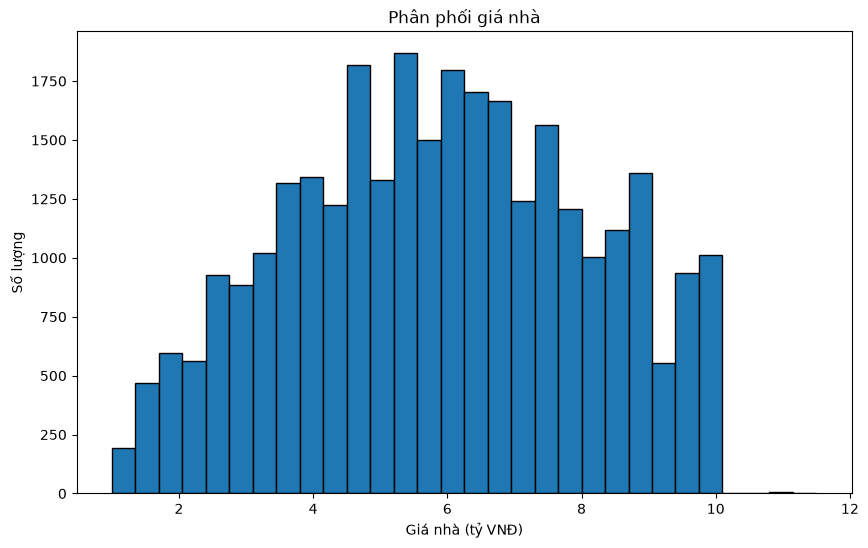

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["Price"],
    bins=30,
    edgecolor="black"
)

plt.title("Phân phối giá nhà")
plt.xlabel("Giá nhà (tỷ VNĐ)")
plt.ylabel("Số lượng")

plt.show()

### Nhận xét

Biểu đồ thể hiện phân phối giá nhà trong bộ dữ liệu. Giá nhà dao động từ
khoảng 1 tỷ đến 11,5 tỷ VNĐ. Phần lớn các bất động sản tập trung trong
khoảng giá trung bình, trong khi số lượng bất động sản ở mức giá rất cao
thấp hơn.

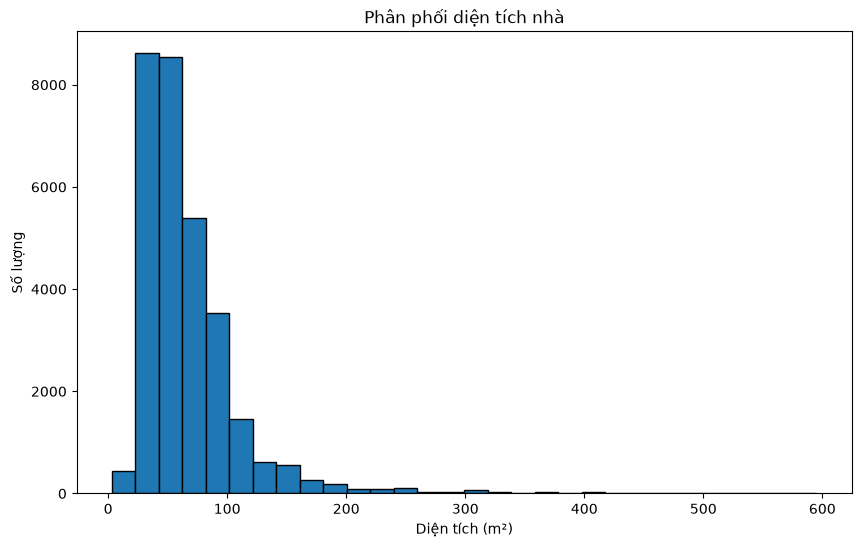

In [26]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["Area"],
    bins=30,
    edgecolor="black"
)

plt.title("Phân phối diện tích nhà")
plt.xlabel("Diện tích (m²)")
plt.ylabel("Số lượng")

plt.show()

### Nhận xét

Phần lớn bất động sản có diện tích tập trung ở nhóm diện tích nhỏ và trung
bình. Một số bất động sản có diện tích rất lớn, làm cho phân phối có xu
hướng lệch phải. Giá trị trung vị của diện tích là 56 m², trong khi giá trị
lớn nhất đạt 595 m².

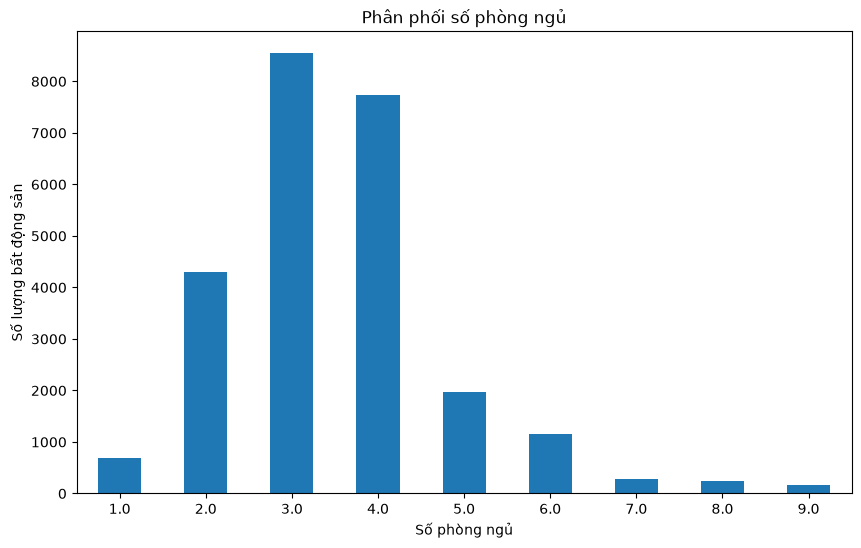

In [27]:
bedroom_counts = (
    df_clean["Bedrooms"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

bedroom_counts.plot(kind="bar")

plt.title("Phân phối số phòng ngủ")
plt.xlabel("Số phòng ngủ")
plt.ylabel("Số lượng bất động sản")

plt.xticks(rotation=0)

plt.show()

### Nhận xét

Số phòng ngủ của các bất động sản trong bộ dữ liệu dao động từ 1 đến 9
phòng. Các căn nhà có khoảng 3 đến 4 phòng ngủ chiếm tỷ trọng đáng kể
trong dữ liệu, trong khi các căn có số lượng phòng ngủ rất lớn xuất hiện
ít hơn.

In [28]:
print("Kích thước dữ liệu:", df_clean.shape)

print("\nCác cột:")
print(df_clean.columns.tolist())

print("\n5 dòng đầu:")
display(df_clean.head())

print("\nMissing values:")
print(df_clean.isnull().sum())

Kích thước dữ liệu: (30229, 13)

Các cột:
['Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price', 'City', 'District']

5 dòng đầu:


,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price,City,District
0,84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60,Hưng Yên,Văn Giang
1,60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50,Hưng Yên,Văn Giang
2,90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90,Hưng Yên,Văn Giang
3,54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35,Hồ Chí Minh,Gò Vấp
4,92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90,Hồ Chí Minh,Gò Vấp



Missing values:
Area                     0
Frontage             11564
Access Road          13297
House direction      21239
Balcony direction    24983
Floors                3603
Bedrooms              5162
Bathrooms             7074
Legal status          4506
Furniture state      14119
Price                    0
City                     0
District                 0
dtype: int64


In [29]:
df_clean["City"].value_counts()

City
Hồ Chí Minh                            11628
Hà Nội                                  9996
Bình Dương                              1655
Đà Nẵng                                 1411
Đồng Nai                                 806
                                       ...  
Quận 8                                     1
Kon Tum.                                   1
TP Hồ Chí Minh                             1
TP. Cam Ranh                               1
Quảng Ninh (Ngã 3 đường Hòn Gai cũ)        1
Name: count, Length: 107, dtype: int64

In [30]:
df_clean["District"].value_counts().head(20)

District
Gò Vấp          1373
Hà Đông         1285
Long Biên       1242
Bình Tân        1159
Thủ Đức         1145
Hoàng Mai       1022
Tân Phú         1015
Đống Đa          983
Quận 12          940
Bình Thạnh       851
Tân Bình         851
Nam Từ Liêm      779
Hai Bà Trưng     771
Thanh Xuân       768
Quận 9           713
Nha Trang        675
Quận 7           644
Dĩ An            592
Biên Hòa         589
Cầu Giấy         571
Name: count, dtype: int64

In [31]:
df_clean["City"] = (
    df_clean["City"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.$", "", regex=True)
)

df_clean["District"] = (
    df_clean["District"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.$", "", regex=True)
)

print("Đã chuẩn hóa khoảng trắng và dấu chấm.")

Đã chuẩn hóa khoảng trắng và dấu chấm.


In [32]:
city_mapping = {
    "TP Hồ Chí Minh": "Hồ Chí Minh",
    "TP. Hồ Chí Minh": "Hồ Chí Minh",
    "TP.Hồ Chí Minh": "Hồ Chí Minh",
    "TP HCM": "Hồ Chí Minh",
    "TP.HCM": "Hồ Chí Minh"
}

df_clean["City"] = df_clean["City"].replace(city_mapping)

In [33]:
print("Số City sau chuẩn hóa:", df_clean["City"].nunique())

print("\n15 City phổ biến nhất:")
print(df_clean["City"].value_counts().head(15))

Số City sau chuẩn hóa: 77

15 City phổ biến nhất:
City
Hồ Chí Minh        11779
Hà Nội             10457
Bình Dương          1672
Đà Nẵng             1437
Đồng Nai             829
Hải Phòng            789
Khánh Hòa            743
Hưng Yên             405
Long An              339
Bà Rịa Vũng Tàu      240
Bắc Ninh             167
Bình Thuận           127
Lâm Đồng             118
Cần Thơ              111
Quảng Ninh           110
Name: count, dtype: int64


## 4. Chuẩn bị dữ liệu huấn luyện

Biến mục tiêu của bài toán là `Price`, biểu diễn giá của bất động sản.
Các thuộc tính còn lại được sử dụng làm đầu vào cho các mô hình hồi quy.

In [34]:
X = df_clean.drop(columns=["Price"])
y = df_clean["Price"]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Kích thước X: (30229, 12)
Kích thước y: (30229,)


### Chia tập dữ liệu

Dữ liệu được chia thành 80% cho quá trình huấn luyện và 20% cho quá trình
kiểm thử. Tập kiểm thử không được sử dụng trong quá trình huấn luyện mô hình.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24183, 12)
X_test : (6046, 12)
y_train: (24183,)
y_test : (6046,)


In [36]:
numeric_features = [
    "Area",
    "Frontage",
    "Access Road",
    "Floors",
    "Bedrooms",
    "Bathrooms"
]

categorical_features = [
    "House direction",
    "Balcony direction",
    "Legal status",
    "Furniture state",
    "City",
    "District"
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']

Categorical features:
['House direction', 'Balcony direction', 'Legal status', 'Furniture state', 'City', 'District']


## 5. Tiền xử lý dữ liệu

Đối với các thuộc tính số, các giá trị bị thiếu được thay thế bằng giá trị
trung vị (median), sau đó dữ liệu được chuẩn hóa bằng StandardScaler.

Đối với các thuộc tính phân loại, giá trị bị thiếu được thay bằng nhãn
`Unknown`, sau đó được chuyển đổi sang dạng số bằng One-Hot Encoding.

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [38]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [39]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Unknown"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Khởi tạo bộ tiền xử lý thành công!")

Khởi tạo bộ tiền xử lý thành công!


## 6. Xây dựng và đánh giá các mô hình học máy

### 6.1 Linear Regression

Linear Regression được sử dụng làm mô hình cơ sở (baseline) cho bài toán
dự đoán giá nhà. Mô hình tìm mối quan hệ tuyến tính giữa các đặc trưng đầu
vào và giá bất động sản.

In [41]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Khởi tạo Linear Regression thành công!")

Khởi tạo Linear Regression thành công!


In [42]:
linear_model.fit(X_train, y_train)

print("Huấn luyện Linear Regression thành công!")

Huấn luyện Linear Regression thành công!


In [44]:
y_pred_linear = linear_model.predict(X_test)

print("Dự đoán thành công!")

Dự đoán thành công!


In [45]:
comparison_linear = pd.DataFrame({
    "Giá thực tế": y_test.values[:10],
    "Giá dự đoán": y_pred_linear[:10]
})

comparison_linear

,Giá thực tế,Giá dự đoán
0,8.30,6.732886
1,5.98,7.933174
2,5.90,5.606091
3,5.65,5.969843
4,8.90,6.755133
5,3.75,3.559649
6,6.50,5.110891
7,4.35,5.218337
8,8.30,6.226622
9,4.00,6.190351


### Các độ đo đánh giá

Năm độ đo được sử dụng để đánh giá các mô hình gồm:

- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)
- R² (Coefficient of Determination)

Đối với MAE, MSE, RMSE và MAPE, giá trị càng nhỏ thì mô hình càng tốt.
Đối với R², giá trị càng gần 1 thì khả năng giải thích dữ liệu của mô hình
càng tốt.

In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

In [48]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

mse_linear = mean_squared_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(mse_linear)

mape_linear = mean_absolute_percentage_error(
    y_test,
    y_pred_linear
) * 100

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

In [49]:
print("LINEAR REGRESSION")
print("============================")

print(f"MAE  : {mae_linear:.4f}")
print(f"MSE  : {mse_linear:.4f}")
print(f"RMSE : {rmse_linear:.4f}")
print(f"MAPE : {mape_linear:.2f}%")
print(f"R2   : {r2_linear:.4f}")

LINEAR REGRESSION
MAE  : 1.2733
MSE  : 2.6840
RMSE : 1.6383
MAPE : 27.16%
R2   : 0.4495


In [50]:
results = []

results.append({
    "Model": "Linear Regression",
    "MAE": mae_linear,
    "MSE": mse_linear,
    "RMSE": rmse_linear,
    "MAPE (%)": mape_linear,
    "R2": r2_linear
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,MAPE (%),R2
0,Linear Regression,1.273349,2.68402,1.638298,27.158642,0.449535


### 6.2 K-Nearest Neighbors Regressor

K-Nearest Neighbors (KNN) dự đoán giá của một bất động sản dựa trên
các bất động sản có đặc trưng gần giống nhất trong tập huấn luyện.

Trong thử nghiệm ban đầu, mô hình sử dụng K = 5, nghĩa là giá dự đoán
được xác định dựa trên 5 mẫu gần nhất.

In [51]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.base import clone

knn_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            KNeighborsRegressor(
                n_neighbors=5,
                weights="distance",
                n_jobs=-1
            )
        )
    ]
)

print("Khởi tạo KNN Regressor thành công!")

Khởi tạo KNN Regressor thành công!


In [53]:
knn_model.fit(X_train, y_train)

print("Huấn luyện KNN Regressor thành công!")

Huấn luyện KNN Regressor thành công!


In [54]:
y_pred_knn = knn_model.predict(X_test)

print("Dự đoán bằng KNN thành công!")

Dự đoán bằng KNN thành công!


In [55]:
comparison_knn = pd.DataFrame({
    "Giá thực tế": y_test.values[:10],
    "Giá dự đoán": y_pred_knn[:10]
})

comparison_knn

,Giá thực tế,Giá dự đoán
0,8.30,6.583095
1,5.98,7.619704
2,5.90,8.000000
3,5.65,6.792785
4,8.90,6.408843
5,3.75,4.585893
6,6.50,4.711806
7,4.35,4.999700
8,8.30,7.804669
9,4.00,7.315909


In [56]:
mae_knn = mean_absolute_error(
    y_test,
    y_pred_knn
)

mse_knn = mean_squared_error(
    y_test,
    y_pred_knn
)

rmse_knn = np.sqrt(mse_knn)

mape_knn = mean_absolute_percentage_error(
    y_test,
    y_pred_knn
) * 100

r2_knn = r2_score(
    y_test,
    y_pred_knn
)

In [57]:
print("KNN REGRESSOR")
print("============================")

print(f"MAE  : {mae_knn:.4f}")
print(f"MSE  : {mse_knn:.4f}")
print(f"RMSE : {rmse_knn:.4f}")
print(f"MAPE : {mape_knn:.2f}%")
print(f"R2   : {r2_knn:.4f}")

KNN REGRESSOR
MAE  : 1.2329
MSE  : 2.6686
RMSE : 1.6336
MAPE : 26.65%
R2   : 0.4527


In [58]:
results.append({
    "Model": "KNN Regressor",
    "MAE": mae_knn,
    "MSE": mse_knn,
    "RMSE": rmse_knn,
    "MAPE (%)": mape_knn,
    "R2": r2_knn
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,MAPE (%),R2
0,Linear Regression,1.273349,2.684020,1.638298,27.158642,0.449535
1,KNN Regressor,1.232944,2.668591,1.633582,26.651028,0.452699


### Nhận xét tạm thời

Linear Regression được sử dụng làm mô hình cơ sở. KNN Regressor được
thử nghiệm nhằm kiểm tra khả năng dự đoán dựa trên sự tương đồng giữa
các bất động sản.

Mô hình có MAE, MSE, RMSE và MAPE thấp hơn đồng thời R² cao hơn sẽ
được xem là có khả năng dự đoán tốt hơn trên tập kiểm thử.

### 6.3 Decision Tree Regressor

Decision Tree Regressor xây dựng mô hình dự đoán dưới dạng cây quyết định.
Dữ liệu được chia thành các nhánh dựa trên giá trị của các thuộc tính đầu vào
để tạo ra giá trị dự đoán cho biến mục tiêu Price.

Mô hình Decision Tree có khả năng biểu diễn các mối quan hệ phi tuyến giữa
đặc trưng của bất động sản và giá nhà.

In [59]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

print("Khởi tạo Decision Tree Regressor thành công!")

Khởi tạo Decision Tree Regressor thành công!


In [60]:
decision_tree_model.fit(X_train, y_train)

print("Huấn luyện Decision Tree Regressor thành công!")

Huấn luyện Decision Tree Regressor thành công!


In [61]:
y_pred_dt = decision_tree_model.predict(X_test)

print("Dự đoán bằng Decision Tree thành công!")

Dự đoán bằng Decision Tree thành công!


In [62]:
comparison_dt = pd.DataFrame({
    "Giá thực tế": y_test.values[:10],
    "Giá dự đoán": y_pred_dt[:10]
})

comparison_dt

,Giá thực tế,Giá dự đoán
0,8.30,9.30
1,5.98,8.60
2,5.90,8.00
3,5.65,5.65
4,8.90,5.50
5,3.75,3.60
6,6.50,2.60
7,4.35,4.70
8,8.30,5.95
9,4.00,6.80


In [63]:
mae_dt = mean_absolute_error(
    y_test,
    y_pred_dt
)

mse_dt = mean_squared_error(
    y_test,
    y_pred_dt
)

rmse_dt = np.sqrt(mse_dt)

mape_dt = mean_absolute_percentage_error(
    y_test,
    y_pred_dt
) * 100

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

In [64]:
print("DECISION TREE REGRESSOR")
print("============================")

print(f"MAE  : {mae_dt:.4f}")
print(f"MSE  : {mse_dt:.4f}")
print(f"RMSE : {rmse_dt:.4f}")
print(f"MAPE : {mape_dt:.2f}%")
print(f"R2   : {r2_dt:.4f}")

DECISION TREE REGRESSOR
MAE  : 1.2636
MSE  : 3.3004
RMSE : 1.8167
MAPE : 25.50%
R2   : 0.3231


In [65]:
results.append({
    "Model": "Decision Tree",
    "MAE": mae_dt,
    "MSE": mse_dt,
    "RMSE": rmse_dt,
    "MAPE (%)": mape_dt,
    "R2": r2_dt
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,MAPE (%),R2
0,Linear Regression,1.273349,2.684020,1.638298,27.158642,0.449535
1,KNN Regressor,1.232944,2.668591,1.633582,26.651028,0.452699
2,Decision Tree,1.263563,3.300409,1.816703,25.495952,0.323120


In [66]:
results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,MSE,RMSE,MAPE (%),R2
1,KNN Regressor,1.232944,2.668591,1.633582,26.651028,0.452699
0,Linear Regression,1.273349,2.684020,1.638298,27.158642,0.449535
2,Decision Tree,1.263563,3.300409,1.816703,25.495952,0.323120


### Nhận xét tạm thời

KNN Regressor hiện cho kết quả tốt hơn một chút so với Linear Regression
trên cả năm độ đo. Tuy nhiên, sự khác biệt giữa hai mô hình chưa lớn.
Do đó, cần tiếp tục thử nghiệm các mô hình Decision Tree, Random Forest
và Gradient Boosting trước khi lựa chọn mô hình tốt nhất.

### 6.4 Random Forest Regressor

Random Forest Regressor là mô hình ensemble sử dụng nhiều cây quyết định
thay vì chỉ một cây duy nhất. Kết quả dự đoán được tổng hợp từ nhiều cây,
giúp giảm hiện tượng overfitting và tăng khả năng khái quát hóa của mô hình.

Trong thử nghiệm này, Random Forest được xây dựng với 100 cây quyết định.

In [67]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Khởi tạo Random Forest Regressor thành công!")

Khởi tạo Random Forest Regressor thành công!


In [68]:
random_forest_model.fit(X_train, y_train)

print("Huấn luyện Random Forest Regressor thành công!")

Huấn luyện Random Forest Regressor thành công!


In [69]:
y_pred_rf = random_forest_model.predict(X_test)

print("Dự đoán bằng Random Forest thành công!")

Dự đoán bằng Random Forest thành công!


In [70]:
comparison_rf = pd.DataFrame({
    "Giá thực tế": y_test.values[:10],
    "Giá dự đoán": y_pred_rf[:10]
})

comparison_rf

,Giá thực tế,Giá dự đoán
0,8.30,7.787000
1,5.98,8.149000
2,5.90,7.300000
3,5.65,5.690000
4,8.90,7.185300
5,3.75,3.648050
6,6.50,3.280200
7,4.35,4.488217
8,8.30,6.036700
9,4.00,6.422374


In [71]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

mape_rf = mean_absolute_percentage_error(
    y_test,
    y_pred_rf
) * 100

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

In [72]:
print("RANDOM FOREST REGRESSOR")
print("============================")

print(f"MAE  : {mae_rf:.4f}")
print(f"MSE  : {mse_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAPE : {mape_rf:.2f}%")
print(f"R2   : {r2_rf:.4f}")

RANDOM FOREST REGRESSOR
MAE  : 1.0070
MSE  : 1.8975
RMSE : 1.3775
MAPE : 21.02%
R2   : 0.6108


In [73]:
results.append({
    "Model": "Random Forest",
    "MAE": mae_rf,
    "MSE": mse_rf,
    "RMSE": rmse_rf,
    "MAPE (%)": mape_rf,
    "R2": r2_rf
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,MAPE (%),R2
0,Linear Regression,1.273349,2.684020,1.638298,27.158642,0.449535
1,KNN Regressor,1.232944,2.668591,1.633582,26.651028,0.452699
2,Decision Tree,1.263563,3.300409,1.816703,25.495952,0.323120
3,Random Forest,1.007011,1.897536,1.377511,21.017711,0.610835


In [74]:
results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

,Model,MAE,MSE,RMSE,MAPE (%),R2
0,Random Forest,1.007011,1.897536,1.377511,21.017711,0.610835
1,KNN Regressor,1.232944,2.668591,1.633582,26.651028,0.452699
2,Linear Regression,1.273349,2.684020,1.638298,27.158642,0.449535
3,Decision Tree,1.263563,3.300409,1.816703,25.495952,0.323120


### Nhận xét sau bốn mô hình

Các mô hình được đánh giá đồng thời bằng năm độ đo MAE, MSE, RMSE,
MAPE và R². Mô hình tốt cần có MAE, MSE, RMSE và MAPE thấp, đồng thời
có R² cao.

Việc đánh giá không chỉ dựa trên một độ đo duy nhất mà cần xem xét tổng
thể các chỉ số để lựa chọn mô hình có khả năng dự đoán ổn định nhất.

### 6.5 Gradient Boosting Regressor

Gradient Boosting Regressor là một phương pháp ensemble xây dựng nhiều cây
quyết định theo tuần tự. Mỗi cây mới được huấn luyện nhằm cải thiện các sai
số còn lại của các cây trước đó.

Khác với Random Forest xây dựng nhiều cây tương đối độc lập, Gradient
Boosting xây dựng các cây liên tiếp để từng bước cải thiện khả năng dự đoán.

In [75]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

print("Khởi tạo Gradient Boosting Regressor thành công!")

Khởi tạo Gradient Boosting Regressor thành công!


In [76]:
gradient_boosting_model.fit(X_train, y_train)

print("Huấn luyện Gradient Boosting Regressor thành công!")

Huấn luyện Gradient Boosting Regressor thành công!


In [77]:
y_pred_gb = gradient_boosting_model.predict(X_test)

print("Dự đoán bằng Gradient Boosting thành công!")

Dự đoán bằng Gradient Boosting thành công!


In [78]:
comparison_gb = pd.DataFrame({
    "Giá thực tế": y_test.values[:10],
    "Giá dự đoán": y_pred_gb[:10]
})

comparison_gb

,Giá thực tế,Giá dự đoán
0,8.30,6.958413
1,5.98,7.533791
2,5.90,5.261160
3,5.65,6.659357
4,8.90,6.930748
5,3.75,4.503729
6,6.50,5.256764
7,4.35,4.421787
8,8.30,6.269661
9,4.00,6.013258


In [79]:
mae_gb = mean_absolute_error(
    y_test,
    y_pred_gb
)

mse_gb = mean_squared_error(
    y_test,
    y_pred_gb
)

rmse_gb = np.sqrt(mse_gb)

mape_gb = mean_absolute_percentage_error(
    y_test,
    y_pred_gb
) * 100

r2_gb = r2_score(
    y_test,
    y_pred_gb
)

In [80]:
print("GRADIENT BOOSTING REGRESSOR")
print("============================")

print(f"MAE  : {mae_gb:.4f}")
print(f"MSE  : {mse_gb:.4f}")
print(f"RMSE : {rmse_gb:.4f}")
print(f"MAPE : {mape_gb:.2f}%")
print(f"R2   : {r2_gb:.4f}")

GRADIENT BOOSTING REGRESSOR
MAE  : 1.2505
MSE  : 2.4942
RMSE : 1.5793
MAPE : 27.89%
R2   : 0.4885


In [81]:
results.append({
    "Model": "Gradient Boosting",
    "MAE": mae_gb,
    "MSE": mse_gb,
    "RMSE": rmse_gb,
    "MAPE (%)": mape_gb,
    "R2": r2_gb
})

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,MAPE (%),R2
0,Linear Regression,1.273349,2.684020,1.638298,27.158642,0.449535
1,KNN Regressor,1.232944,2.668591,1.633582,26.651028,0.452699
2,Decision Tree,1.263563,3.300409,1.816703,25.495952,0.323120
3,Random Forest,1.007011,1.897536,1.377511,21.017711,0.610835
4,Gradient Boosting,1.250547,2.494203,1.579304,27.889460,0.488465


In [82]:
final_results = results_df.copy()

final_results[
    ["MAE", "MSE", "RMSE", "MAPE (%)", "R2"]
] = final_results[
    ["MAE", "MSE", "RMSE", "MAPE (%)", "R2"]
].round(4)

final_results

,Model,MAE,MSE,RMSE,MAPE (%),R2
0,Linear Regression,1.2733,2.6840,1.6383,27.1586,0.4495
1,KNN Regressor,1.2329,2.6686,1.6336,26.6510,0.4527
2,Decision Tree,1.2636,3.3004,1.8167,25.4960,0.3231
3,Random Forest,1.0070,1.8975,1.3775,21.0177,0.6108
4,Gradient Boosting,1.2505,2.4942,1.5793,27.8895,0.4885


In [83]:
final_results_sorted = final_results.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

final_results_sorted

,Model,MAE,MSE,RMSE,MAPE (%),R2
0,Random Forest,1.0070,1.8975,1.3775,21.0177,0.6108
1,Gradient Boosting,1.2505,2.4942,1.5793,27.8895,0.4885
2,KNN Regressor,1.2329,2.6686,1.6336,26.6510,0.4527
3,Linear Regression,1.2733,2.6840,1.6383,27.1586,0.4495
4,Decision Tree,1.2636,3.3004,1.8167,25.4960,0.3231


### Nhận xét

Trong năm mô hình đã được thử nghiệm, Random Forest Regressor đạt
kết quả tốt nhất trên cả năm độ đo đánh giá. Mô hình đạt MAE = 1.0070,
MSE = 1.8975, RMSE = 1.3775, MAPE = 21.02% và R² = 0.6108.

So với một cây Decision Tree đơn lẻ, Random Forest cho kết quả tốt hơn
đáng kể. Điều này cho thấy việc kết hợp nhiều cây quyết định giúp mô hình
có khả năng khái quát hóa tốt hơn trên tập dữ liệu kiểm thử.

Kết quả này cho thấy Random Forest Regressor là mô hình phù hợp nhất
trong số năm mô hình được thử nghiệm trên tập kiểm thử.

In [ ]:
## 7. So sánh và lựa chọn mô hình tốt nhất

Sau quá trình huấn luyện và đánh giá năm mô hình gồm Linear Regression,
KNN Regressor, Decision Tree Regressor, Random Forest Regressor và
Gradient Boosting Regressor, kết quả cho thấy Random Forest Regressor
đạt hiệu quả tốt nhất trên cả năm độ đo.

Cụ thể, Random Forest đạt:

- MAE = 1.0070
- MSE = 1.8975
- RMSE = 1.3775
- MAPE = 21.0177%
- R² = 0.6108

Random Forest có MAE, MSE, RMSE và MAPE thấp nhất, đồng thời có R²
cao nhất trong năm mô hình được thử nghiệm. Vì vậy, Random Forest
Regressor được lựa chọn làm mô hình cuối cùng để triển khai chức năng
dự đoán giá nhà trên ứng dụng Mobile.

### Nhận xét về Random Forest

MAE = 1.0070 cho thấy sai số tuyệt đối trung bình giữa giá dự đoán và
giá thực tế khoảng 1.007 tỷ VNĐ.

RMSE = 1.3775 tỷ VNĐ cho thấy mô hình vẫn tồn tại một số dự đoán có
sai số tương đối lớn.

MAPE = 21.0177% cho thấy trung bình giá dự đoán sai lệch khoảng 21.02%
so với giá thực tế.

R² = 0.6108 cho thấy mô hình giải thích được khoảng 61.08% sự biến thiên
của giá nhà trong tập kiểm thử.

Nhìn chung, Random Forest cho kết quả tốt nhất trong năm thuật toán được
thử nghiệm và được lựa chọn để triển khai.

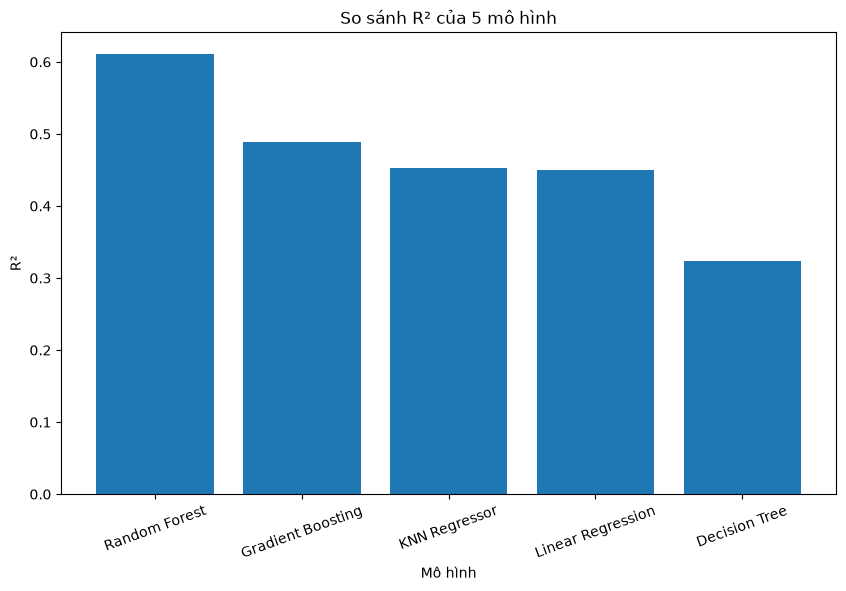

In [84]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_results_sorted["Model"],
    final_results_sorted["R2"]
)

plt.title("So sánh R² của 5 mô hình")
plt.xlabel("Mô hình")
plt.ylabel("R²")

plt.xticks(rotation=20)

plt.show()

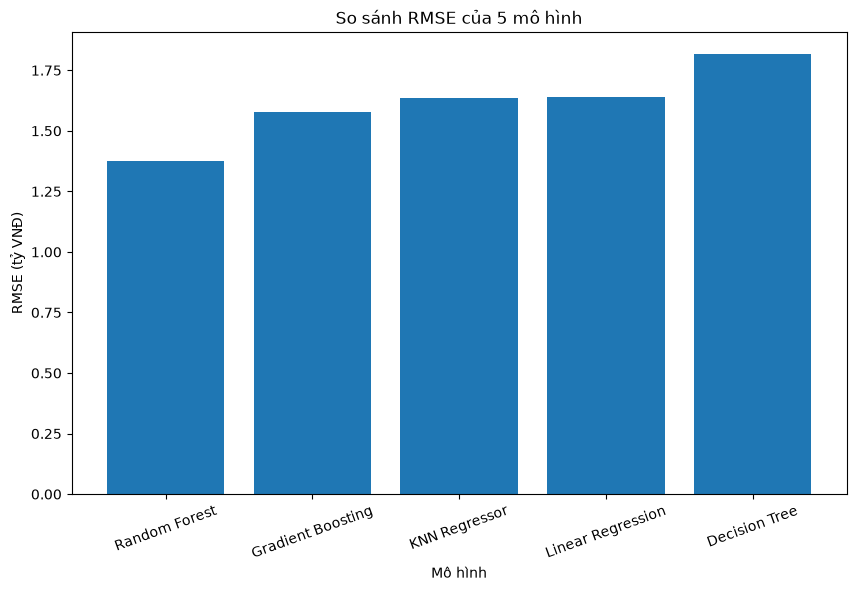

In [85]:
rmse_sorted = final_results.sort_values(
    by="RMSE",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.bar(
    rmse_sorted["Model"],
    rmse_sorted["RMSE"]
)

plt.title("So sánh RMSE của 5 mô hình")
plt.xlabel("Mô hình")
plt.ylabel("RMSE (tỷ VNĐ)")

plt.xticks(rotation=20)

plt.show()

In [86]:
best_row = final_results.loc[
    final_results["R2"].idxmax()
]

print("Mô hình có R² cao nhất:")
print(best_row)

Mô hình có R² cao nhất:
Model       Random Forest
MAE                 1.007
MSE                1.8975
RMSE               1.3775
MAPE (%)          21.0177
R2                 0.6108
Name: 3, dtype: object


## 8. Huấn luyện mô hình cuối cùng

Sau khi Random Forest được xác định là mô hình tốt nhất, mô hình được
huấn luyện lại trên toàn bộ dữ liệu nhằm tận dụng tối đa số lượng mẫu
trước khi triển khai vào hệ thống thực tế.

In [87]:
final_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [88]:
final_model.fit(X, y)

print("Huấn luyện mô hình Random Forest cuối cùng thành công!")

Huấn luyện mô hình Random Forest cuối cùng thành công!


## 9. Lưu mô hình

Mô hình Random Forest cùng toàn bộ quá trình tiền xử lý dữ liệu được
lưu lại bằng Joblib. Việc lưu toàn bộ Pipeline giúp đảm bảo dữ liệu mới
sẽ được xử lý theo đúng cách đã sử dụng khi huấn luyện trước khi thực hiện
dự đoán.

In [89]:
import joblib

model_filename = "house_price_random_forest.pkl"

joblib.dump(
    final_model,
    model_filename
)

print("Đã lưu model:", model_filename)

Đã lưu model: house_price_random_forest.pkl


In [90]:
loaded_model = joblib.load(
    "house_price_random_forest.pkl"
)

print("Load model thành công!")

Load model thành công!


In [91]:
sample_house = X.iloc[[0]]

sample_house

,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,City,District
0,84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,Hưng Yên,Văn Giang


In [92]:
predicted_price = loaded_model.predict(
    sample_house
)[0]

actual_price = y.iloc[0]

print(f"Giá thực tế : {actual_price:.2f} tỷ VNĐ")
print(f"Giá dự đoán : {predicted_price:.2f} tỷ VNĐ")

Giá thực tế : 8.60 tỷ VNĐ
Giá dự đoán : 8.80 tỷ VNĐ


In [93]:
print(X.columns.tolist())

['Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'City', 'District']


In [ ]:
new_house = pd.DataFrame([{
    "Area": 60,
    "Frontage": 5,
    "Access Road": 6,
    "House direction": "Đông - Nam",
    "Balcony direction": "Đông",
    "Floors": 3,
    "Bedrooms": 3,
    "Bathrooms": 2,
    "Legal status": "Have certificate",
    "Furniture state": "Full",
    "City": "Hà Nội",
    "District": "Hà Đông"
}])

new_house

In [95]:
new_prediction = loaded_model.predict(
    new_house
)[0]

print(
    f"Giá nhà dự đoán: {new_prediction:.2f} tỷ VNĐ"
)

Giá nhà dự đoán: 6.67 tỷ VNĐ


## 10. Kết luận

Trong bài toán dự đoán giá nhà, năm thuật toán học máy đã được xây dựng
và thử nghiệm gồm Linear Regression, KNN Regressor, Decision Tree
Regressor, Random Forest Regressor và Gradient Boosting Regressor.

Các mô hình được đánh giá trên cùng tập kiểm thử bằng năm độ đo MAE,
MSE, RMSE, MAPE và R².

Kết quả thực nghiệm cho thấy Random Forest Regressor đạt kết quả tốt nhất
với MAE = 1.0070, MSE = 1.8975, RMSE = 1.3775, MAPE = 21.0177% và
R² = 0.6108.

Do đó, Random Forest Regressor được lựa chọn làm mô hình cuối cùng.
Mô hình sau đó được huấn luyện lại trên toàn bộ dữ liệu và lưu dưới dạng
file `house_price_random_forest.pkl` để phục vụ cho việc triển khai chức
năng dự đoán giá nhà trên ứng dụng Mobile.

In [97]:
!pip install flask


   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   ---------------------------------------- 0/5 [werkzeug]
   -------- ------------------------------- 1/5 [itsdangerous]
   -------- ------------------------------- 1/5 [itsdangerous]
   ---------------- ----------------------- 2/5 [click]
   ---------------- ----------------------- 2/5 [click]
   ---------------- ----------------------- 2/5 [click]
   ---------------- ----------------------- 2/5 [click]
   -------------------------------- ------- 4/5 [flask]
   


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\LAPTOP\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [98]:
import flask

print("Flask version:", flask.__version__)

Flask version: 3.1.3


In [101]:
%%writefile app.py

from flask import Flask, request, jsonify
import pandas as pd
import joblib

app = Flask(__name__)

# Load mô hình đã huấn luyện
model = joblib.load("house_price_random_forest.pkl")


@app.route("/", methods=["GET"])
def home():
    return jsonify({
        "message": "House Price Prediction API is running"
    })


@app.route("/predict", methods=["POST"])
def predict():

    try:
        data = request.get_json()

        required_fields = [
            "Area",
            "Frontage",
            "Access Road",
            "House direction",
            "Balcony direction",
            "Floors",
            "Bedrooms",
            "Bathrooms",
            "Legal status",
            "Furniture state",
            "City",
            "District"
        ]

        # Kiểm tra các trường đầu vào
        missing_fields = [
            field for field in required_fields
            if field not in data
        ]

        if missing_fields:
            return jsonify({
                "error": "Missing fields",
                "fields": missing_fields
            }), 400

        # Chuyển dữ liệu JSON thành DataFrame
        input_data = pd.DataFrame([{
            "Area": data["Area"],
            "Frontage": data["Frontage"],
            "Access Road": data["Access Road"],
            "House direction": data["House direction"],
            "Balcony direction": data["Balcony direction"],
            "Floors": data["Floors"],
            "Bedrooms": data["Bedrooms"],
            "Bathrooms": data["Bathrooms"],
            "Legal status": data["Legal status"],
            "Furniture state": data["Furniture state"],
            "City": data["City"],
            "District": data["District"]
        }])

        # Dự đoán
        prediction = model.predict(input_data)[0]

        return jsonify({
            "predicted_price": round(float(prediction), 2),
            "unit": "billion VND"
        })

    except Exception as e:

        return jsonify({
            "error": str(e)
        }), 500


if __name__ == "__main__":
    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False
    )

Writing app.py


In [102]:
import os

for file in os.listdir("."):
    if file.endswith((".py", ".pkl", ".ipynb")):
        print(file)

app.py
gianhadat.ipynb
house_price_random_forest.pkl
Untitled.ipynb


In [103]:
import requests

In [104]:
test_house = {
    "Area": 60,
    "Frontage": 5,
    "Access Road": 6,
    "House direction": "Đông - Nam",
    "Balcony direction": "Đông",
    "Floors": 3,
    "Bedrooms": 3,
    "Bathrooms": 2,
    "Legal status": "Have certificate",
    "Furniture state": "Full",
    "City": "Hà Nội",
    "District": "Hà Đông"
}

In [105]:
response = requests.post(
    "http://127.0.0.1:5000/predict",
    json=test_house
)

print("Status code:", response.status_code)
print("Response:", response.json())

Status code: 200
Response: {'predicted_price': 6.67, 'unit': 'billion VND'}


In [106]:
test_house_2 = {
    "Area": 80,
    "Frontage": 6,
    "Access Road": 8,
    "House direction": "Nam",
    "Balcony direction": "Đông - Nam",
    "Floors": 4,
    "Bedrooms": 4,
    "Bathrooms": 3,
    "Legal status": "Have certificate",
    "Furniture state": "Full",
    "City": "Hồ Chí Minh",
    "District": "Gò Vấp"
}

response = requests.post(
    "http://127.0.0.1:5000/predict",
    json=test_house_2
)

print(response.json())

{'predicted_price': 8.26, 'unit': 'billion VND'}


## 11. Triển khai mô hình dưới dạng REST API

Sau khi Random Forest Regressor được lựa chọn và lưu lại, mô hình được
triển khai dưới dạng REST API bằng Flask.

API cung cấp endpoint `/predict` sử dụng phương thức POST. Ứng dụng client
gửi thông tin của bất động sản dưới dạng JSON. Flask chuyển dữ liệu đầu vào
thành DataFrame và sử dụng mô hình Random Forest đã huấn luyện để thực hiện
dự đoán.

Kết quả dự đoán được trả về cho client dưới dạng JSON và có thể được sử dụng
bởi ứng dụng Mobile để hiển thị giá nhà dự đoán cho người dùng.